Intercept:  -0.1419901696398096
Coefficients:  [ 0.07054431  0.23961665 -0.04017846]
RMSE:  0.23741163227877007
R2:  0.9976528964645683
    variable       VIF
0      const  1.577684
1         TV  1.577684
2      Radio  1.577684
3  Newspaper  1.577684


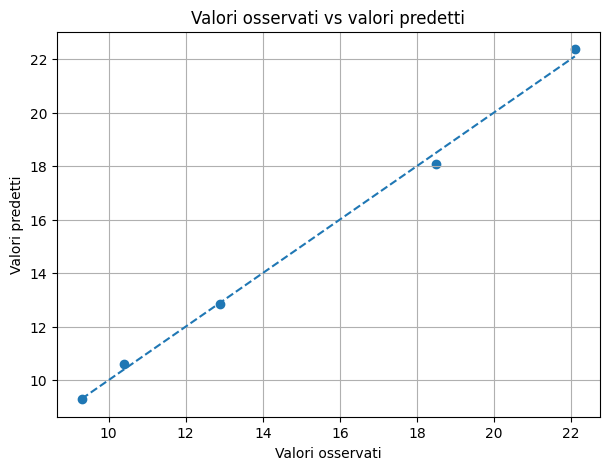

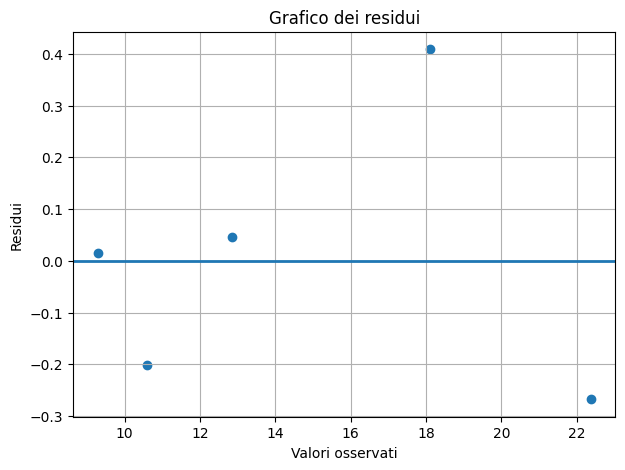

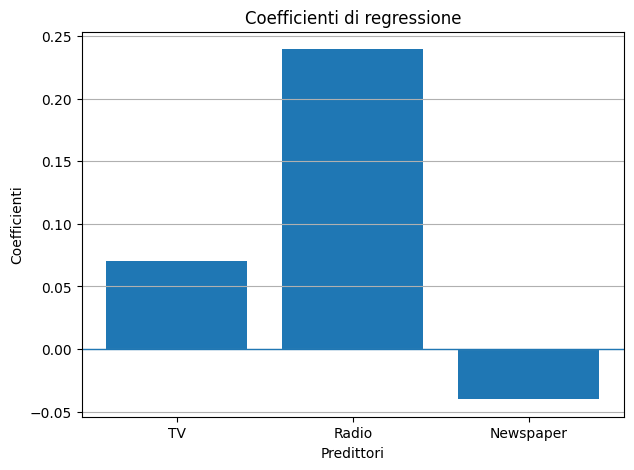

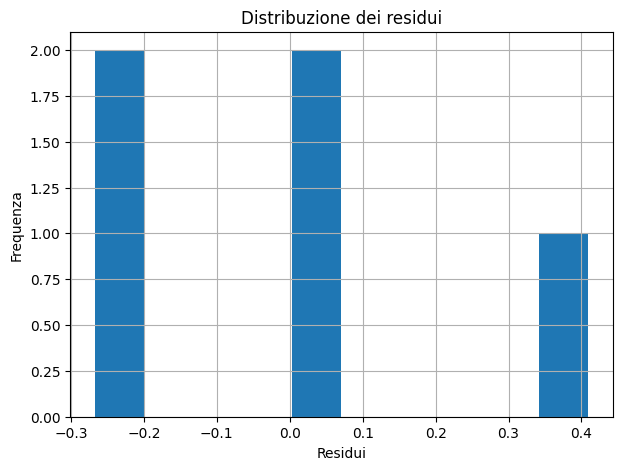

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# esempio di dataset
data = {
    'TV' : [230.1,44.5,17.2,151.5,180.8],
    'Radio' : [37.8, 39.3,45.9,41.3,10.8],
    'Newspaper' : [69.2,45.1,69.3,58.5,58.4],
    'Sales' : [22.1,10.4,9.3,18.5,12.9]
}

df = pd.DataFrame(data)

# Separazione predittori / target
X = df[['TV','Radio','Newspaper']]
y = df['Sales']

# Modello con scikit-learn
model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)

print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

# Valutazione
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y,y_pred)

print("RMSE: ", rmse)
print("R2: ", r2)

# Calcolo VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X)
vif = pd.DataFrame()
vif['variable'] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values,1) for i in range(X_vif.shape[1])]

print(vif)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y,y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--' )
plt.xlabel("Valori osservati")
plt.ylabel("Valori predetti")
plt.title("Valori osservati vs valori predetti")
plt.grid(True)
plt.show()


#  Grafico dei residui

residuals = y-y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, linewidth=2)
plt.xlabel("Valori osservati")
plt.ylabel("Residui")
plt.title("Grafico dei residui")
plt.grid(True)
plt.show()

# Visualizzazione dei coefficienti

coefficientrs = model.coef_
features = X.columns

plt.figure(figsize=(7,5))
plt.bar(features,coefficientrs)
plt.axhline(0, linewidth=1)
plt.xlabel("Predittori")
plt.ylabel("Coefficienti")
plt.title("Coefficienti di regressione")
plt.grid(axis='y')
plt.show()

# Distribuzione dei residui

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=10)
plt.xlabel("Residui")
plt.ylabel("Frequenza")
plt.title("Distribuzione dei residui")
plt.grid(True)
plt.show()